In [1]:
# set root 
from pathlib import Path
import sys
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

In this notebook, we provide additional details on the modeling process, including the hyperparameter tuning and training steps. Our data science problem is as follows: given historical weather features $X_t$, temporal features $\tau(t)$ and previous counts $Y^{d}_{t-1}, \ldots, Y^{d}_{t-k_{AR}}$, we want to predict the cumulative count of FTCs for the next $d$ days, denoted as $Y^d_t$. We use three models for this task: 

1. Negative binomial and poisson generalized linear models (GLMs), 
2. An XGBoost regression model trained with the poisson count objective (maximum likelihood 
for the poisson distribution), and 
3. An XGBoost + SARIMA model where we first fit an XGBoost model to the counts data and then fit a SARIMA model to the residuals: 
$$ Y^{d}_{t} = XGB(X_{t}, \tau_t, Y^{d}_{t-1}, \ldots, Y^{d}_{t-k_{AR}}) + SARIMA(Y^{d}_{t-1}, \ldots, Y^{d}_{t-k_{AR}})$$

# Getting data and models using hydra for training

We use hydra to manage our configurations for data preprocessing, model training and hyperparameter tuning. Hydra allows us to easily switch between different configurations and track our experiments. The configuration files are located in the `config` directory, where we have separate files for data preprocessing (`data_preprocessing.yaml`), model training (`model_training.yaml`) and hyperparameter tuning (`hyperparameter_tuning.yaml`).

In [2]:
# Load default config and build daily series
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra

GlobalHydra.instance().clear()
config_dir = str(ROOT / "configs")
with initialize_config_dir(config_dir=config_dir, version_base=None):
    cfg = compose(config_name="config")


We first get the pre-processed pothole and weather data using our built in functions `build_daily`:

In [3]:
from modeling.data.master import build_daily
cfg.debug.verbose = False
pothole_df, weather_df = build_daily(cfg)
print(f"Loaded: pothole_df {len(pothole_df)} rows, weather_df {len(weather_df)} rows")

Loaded: pothole_df 1826 rows, weather_df 2040 rows


Our features are constructed as the lagged rolling sums or averages of weather variables. We can take a look at the different lags, window sizes and the autoregression size through `cfg.features`: 

In [4]:
cfg.features

{'d': 1, 'd_p': 15, 'l_p': 10, 'd_s': 15, 'l_s': 0, 'd_f': 15, 'l_f': 0, 'k_AR': 0}

We now construct these features usign the parameters. To make a point regarding the autoregressive predictions, we purposely change the value of `k_AR` to 10 so that the model uses the previous 10 `Y` values as features.

In [6]:
# get the data split 
cfg.features.k_AR = 2 # use the previous 10 `Y` values as features
from modeling.features import assemble_features
from modeling.split import make_split
feat_df = assemble_features(pothole_df, weather_df, cfg.features) 
feat_df = make_split(feat_df, cfg.split) # split the data into train, val, and test sets
feature_cols = [c for c in feat_df.columns if c not in ("date", "Y", "split")]

[assemble_features] kept 1823/1826 rows (99.8%) after dropping NaNs


In [31]:
import pandas as pd
train_min, train_max = pd.to_datetime(feat_df[feat_df["split"] == "train"].date).min(), pd.to_datetime(feat_df[feat_df["split"] == "train"].date).max()
val_min, val_max = pd.to_datetime(feat_df[feat_df["split"] == "val"].date).min(), pd.to_datetime(feat_df[feat_df["split"] == "val"].date).max()
test_min, test_max = pd.to_datetime(feat_df[feat_df["split"] == "test"].date).min(), pd.to_datetime(feat_df[feat_df["split"] == "test"].date).max()
print(f"Train: {train_min} to {train_max}, \n Val: {val_min} to {val_max}, \n Test: {test_min} to {test_max}")

Train: 2021-01-03 00:00:00 to 2024-07-02 00:00:00, 
 Val: 2024-07-03 00:00:00 to 2025-04-01 00:00:00, 
 Test: 2025-04-02 00:00:00 to 2025-12-30 00:00:00


Next, we construct the model using our `build_model` function implemented in `modeling/models.py`.

In [7]:
# get model 
from modeling.models import build_model
train_df = feat_df[feat_df["split"] == "train"]
X_train = train_df[feature_cols]
y_train = train_df["Y"] # get the target for the train set
model = build_model(cfg.model) # build the model

In [8]:
model.fit(X_train, y_train) # fit the model on the train set

/data/rpan/miniconda3/envs/dsproj/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


# Model predicition and evaluation

We now evaluate the model on the validation set. Here we address the issue of autoregressive predictions. Since the model uses the previous 2 `Y` values as features, when we get up to the validation set, we need to use the model's own predictions for these features when making predictions on the validation set. This is done through a loop where we iteratively predict the next value and then use that prediction as a feature for the next prediction, controlled by the flag `recursive = True` in the `predict` function.

In [9]:
X_val = feat_df[feat_df["split"] == "val"][feature_cols]
y_val = feat_df[feat_df["split"] == "val"]["Y"]
y_val_pred = model.predict(X_val, recursive=True) # get predictions on the validation set

Using recursive prediction with k_AR = {k_AR}


Let's plot the predictions. This was a very simple model without having the hyperparameters tuned,so we don't expect the best predictions: 

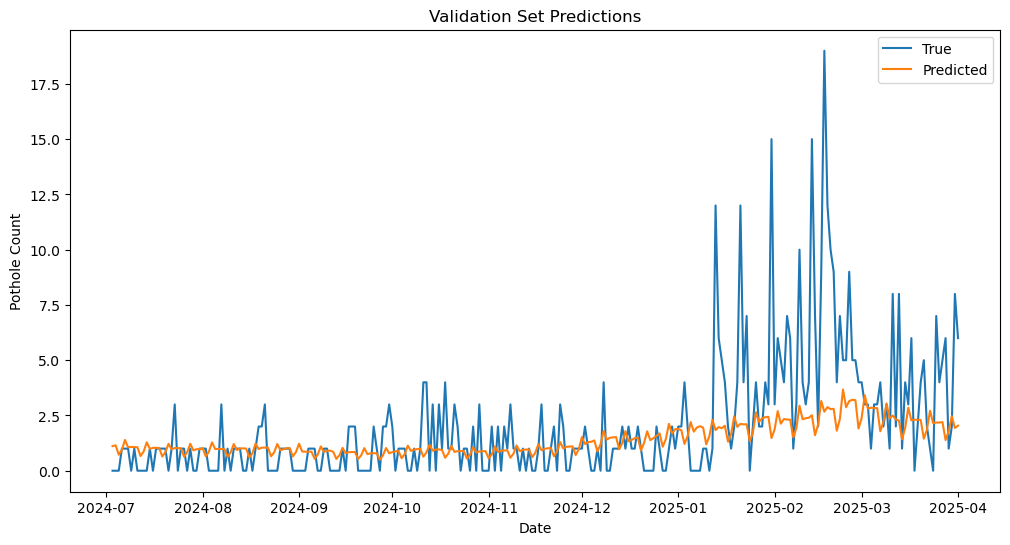

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(feat_df[feat_df["split"] == "val"]["date"], y_val, label="True")
plt.plot(feat_df[feat_df["split"] == "val"]["date"], y_val_pred, label="Predicted")
plt.legend()
plt.title("Validation Set Predictions")
plt.xlabel("Date")
plt.ylabel("Pothole Count")
plt.show()
         